# Car Price Exploratory Data Analysis 



**Objective:** To understand the underlying distributions, identify missing data patterns, and map out feature correlations before training our Machine Learning model. This ensures our `LinearRegression` pipeline is fed high-quality, normalized data.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3

# Set styling for professional-looking plots
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

#Connect to SQLite database
conn = sqlite3.connect('../database/car_data.db')

# Load the data
# Safely load table from the SQLite DB (handles missing 'cars' table)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
if 'cars' in tables['name'].values:
    df = pd.read_sql_query("SELECT * FROM cars", conn)
elif not tables.empty:
    table = tables['name'].iat[0]
    print(f"'cars' table not found. Available tables: {tables['name'].tolist()}. Reading '{table}' instead.")
    df = pd.read_sql_query(f'SELECT * FROM "{table}"', conn)
else:
    raise RuntimeError("No tables found in the database.")

# Now close the connection to the database
conn.close()

#
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (3640, 6)


,id,make,model,mileage,engine_size,price
0,7289,SKODA,Fabia,70189,1.4,6900.0
1,7290,Vauxhall,Corsa,88585,1.2,1495.0
2,7291,Hyundai,i30,137000,1.4,949.0
3,7292,MINI,Hatch,96731,1.4,2395.0
4,7293,Vauxhall,Corsa,85000,1.3,1000.0


**Schema and Missing Values Checks**

In [7]:
# Analyze data types and missing values
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3640 entries, 0 to 3639
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           3640 non-null   int64  
 1   make         3640 non-null   object 
 2   model        3640 non-null   object 
 3   mileage      3640 non-null   int64  
 4   engine_size  3640 non-null   float64
 5   price        3640 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 170.8+ KB

--- Missing Values ---
Series([], dtype: int64)


## 1. Target Variable Distribution (Price)
So we are going for the understanding the distribution of our target variable is critical. Highly skewed prices might require a log transformation to prevent our regression model from heavily biasing towards expensive outlier cars.

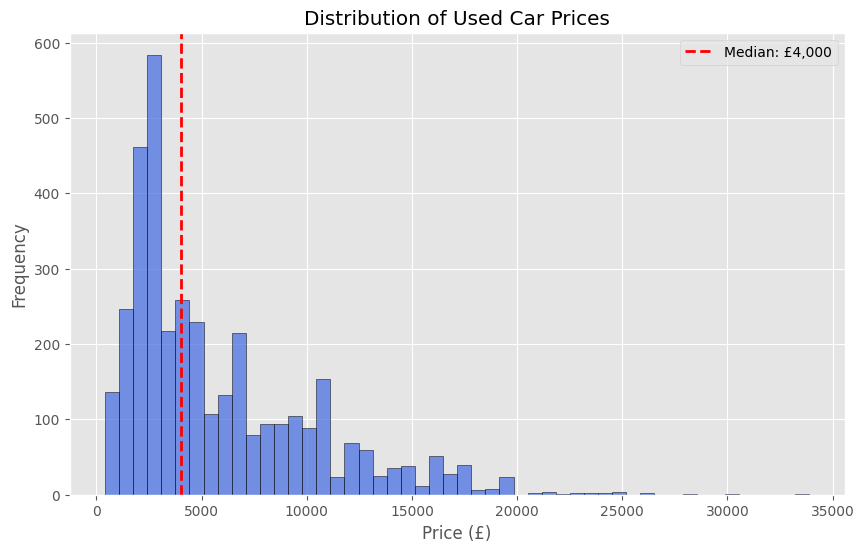

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'].dropna(), bins=50, color='royalblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')

# Adding a median line
plt.axvline(df['price'].median(), color='red', linestyle='dashed', linewidth=2, label=f"Median: £{df['price'].median():,.0f}")
plt.legend()
plt.show()

## 2. Correlation Matrix


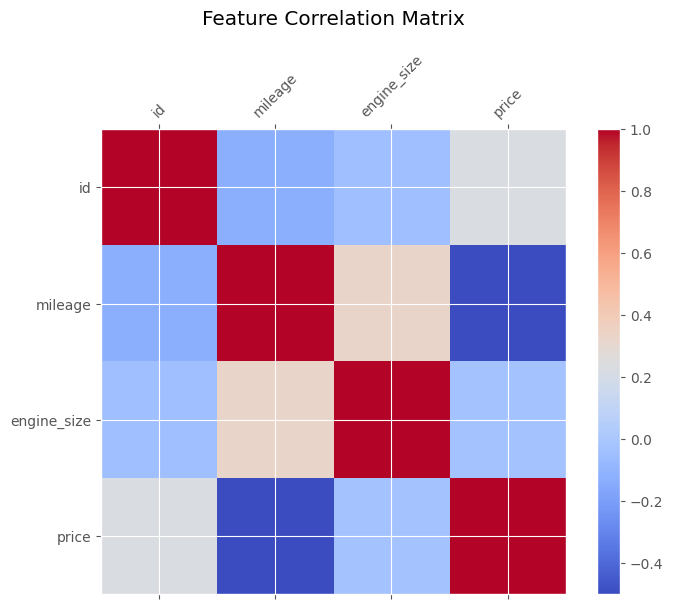

Correlation with Price:
price          1.000000
id             0.228570
engine_size   -0.022697
mileage       -0.500316
Name: price, dtype: float64


In [9]:
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
correlation_matrix = numerical_df.corr()

# Using matplotlib's matshow to plot the correlation matrix
cax = plt.matshow(correlation_matrix, cmap='coolwarm', fignum=1)
plt.colorbar(cax)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Feature Correlation Matrix', pad=20)
plt.show()

print("Correlation with Price:")
print(correlation_matrix['price'].sort_values(ascending=False))

**Conclusion**  
1. Mileage is the strongest predictor of cars a price as theres a Strong Negative Correlation (-0.4 -to -0.5)
2. Engine size has negligble effect on the price of car (0 or -0.1)
3. Most importantly the multicollinearity It shows a very weak positive correlation. If two of your features were highly correlated (e.g., dark red), we would have high multicollinearity, whic could confuse our ML model